# London vs Seattle Rain Precipitation

## 1. Project Description

Seattle and London are both well known for having rainy and cloudy weather, but which city actually receives more precipitation? This project compares daily precipitation in Seattle, Washington, and London, United Kingdom, from 2018 through 2022.
The goal of the analysis is to determine whether there is a meaningful difference in precipitation between the two cities and to explore how their rainfall patterns vary throughout the year. By examining daily, monthly, and yearly precipitation data, as well as using statistical analysis, this project provides a data-based comparison of the climates of these two famously rainy cities.

### 1.1 Data Source

The precipitation data used in this project was obtained from the National Oceanic and Atmospheric Administration (NOAA).
For this analysis, daily precipitation observations were collected for Seattle, Washington (SEA) and London, United Kingdom (LDN) covering the period from January 1, 2018, through December 31, 2022. The original datasets included information such as the weather station, station name, date, and daily precipitation measurements. The data was cleaned and standardized to create a dataset containing the date, city, precipitation, and date of the year.

Data source: National Oceanic and Atmospheric Administration (NOAA)

(NOAA)website: https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND

### 1.2 Load and explore the data

### Import the libraries

Those are the libraries we will be using to help with data cleaning, manipulation, and visualization. 

In [10]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn 
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

### Load the data

#### Load London dataset

In [13]:
df_london = pd.read_csv("/Users/marianabutarov/Data_Science/Weather Project/London.csv")

#### Load Seattle dataset

In [15]:
df_seattle = pd.read_csv("/Users/marianabutarov/Data_Science/Weather Project/seattle_rain.csv")

## 2. Exploring contents of the dataset

#### 2.1 Use the info method to check the data types, size of the data frames, and numbers of missing values

In [18]:
df_london.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1823 entries, 0 to 1822
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1823 non-null   object 
 1   NAME     1823 non-null   object 
 2   DATE     1823 non-null   object 
 3   PRCP     1799 non-null   float64
dtypes: float64(1), object(3)
memory usage: 57.1+ KB


Using the `.info()` method helps us understand the structure of our dataset. Here, we can see that the London dataset contains four columns: `STATION`, `NAME`, `DATE`, and `PRCP` (precipitation).

The **Non-Null Count** shows how many values in each column are not missing, which can help us identify whether the dataset contains missing data. We can also see the data type (`Dtype`) of each column. `STATION`, `NAME`, and `DATE` are stored as objects, while `PRCP` is stored as a `float64`, since precipitation is represented using numerical values.

In [20]:
df_seattle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   object 
 1   NAME     1658 non-null   object 
 2   DATE     1658 non-null   object 
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), object(3)
memory usage: 129.7+ KB


The Seattle dataset is a little different from the London dataset. Using the `.info()` method, we can see that the Seattle dataset contains **10 columns**, compared with only four columns in the London dataset. However, we will not be using them all for our analysis.

The columns are `STATION`, `NAME`, `DATE`, `DAPR`, `MDPR`, `PRCP`, `SNOW`, `SNWD`, `WESD`, and `WESF`. The **Non-Null Count** also shows that several columns contain many missing values. For example, `STATION`, `NAME`, and `DATE` each contain 1,658 non-null values, while `PRCP`, which is the main variable used in this analysis, contains 1,636 non-null values. This means that some precipitation observations are missing and will need to be handled during the data-cleaning process.

We can also see that the London dataset contains more entries than the Seattle dataset, with **1,823 rows for London compared with 1,658 rows for Seattle**. This difference will also need to be considered during the data-cleaning process.

Finally, we can see the data type of each column. `STATION`, `NAME`, and `DATE` are stored as objects, while the weather measurement columns, including `PRCP`, are stored as `float64`.

#### 2.2 Examine the STATION column 

In [23]:
df_london['STATION'].nunique()

1

In [24]:
df_seattle['STATION'].nunique()

1

The `.nunique()` method checks how many unique weather stations are present in our dataset. Since weather data can be collected from multiple stations, we want to identify how many different stations were used in each dataset. This is important because weather conditions can vary depending on the location of the station. By comparing data collected under similar conditions, we can make the comparison between Seattle and London more consistent and fair.

#### 2.3 Examine the DATE column

In [27]:
df_london['DATE']

0       2018-01-01
1       2018-01-02
2       2018-01-03
3       2018-01-04
4       2018-01-05
           ...    
1818    2022-12-27
1819    2022-12-28
1820    2022-12-29
1821    2022-12-30
1822    2022-12-31
Name: DATE, Length: 1823, dtype: object

In [28]:
df_seattle['DATE']

0         1/1/18
1         1/2/18
2         1/3/18
3         1/4/18
4         1/5/18
          ...   
1653    12/27/22
1654    12/28/22
1655    12/29/22
1656    12/30/22
1657    12/31/22
Name: DATE, Length: 1658, dtype: object

Previously, when we used the `.info()` method, we were able to see that the `DATE` column was stored as an **object** rather than as a datetime value. This could cause problems when using methods such as `.max()` and `.min()`, or when performing other operations that involve manipulating dates.

Here, we can once again see that the `DATE` column is stored as an object. We can also notice that the dates in the Seattle and London datasets are displayed in different formats. 

#### 2.4 Convert DATE to datetime

In [31]:
df_london['DATE']=pd.to_datetime(df_london['DATE'])

In [32]:
df_seattle['DATE']=pd.to_datetime(df_seattle['DATE'])

/var/folders/j1/t6wf96vj4hq1p8zg7blqq7km0000gn/T/ipykernel_81977/2338518779.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_seattle['DATE']=pd.to_datetime(df_seattle['DATE'])


Before comparing the datasets, we need to convert both `DATE` columns to the `datetime` data type and make sure they follow a consistent format.

#### 2.5 Checking date range

In [35]:
df_london['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

In [36]:
df_seattle['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

Now we can see that the `DATE` column has been converted to the **datetime** data type, which allows us to properly check the date range of our datasets.

Using `.min()` and `.max()`, we can see that the earliest entry is **January 1, 2018**, and the latest entry is **December 31, 2022**, for both cities. This confirms that both datasets cover the same period, which is exactly the date range we wanted for our analysis. Having the same date range for Seattle and London also helps ensure a fair comparison between the two cities.

## 3. Adding some visualization

#### 3.1 Plotting precipitation for London

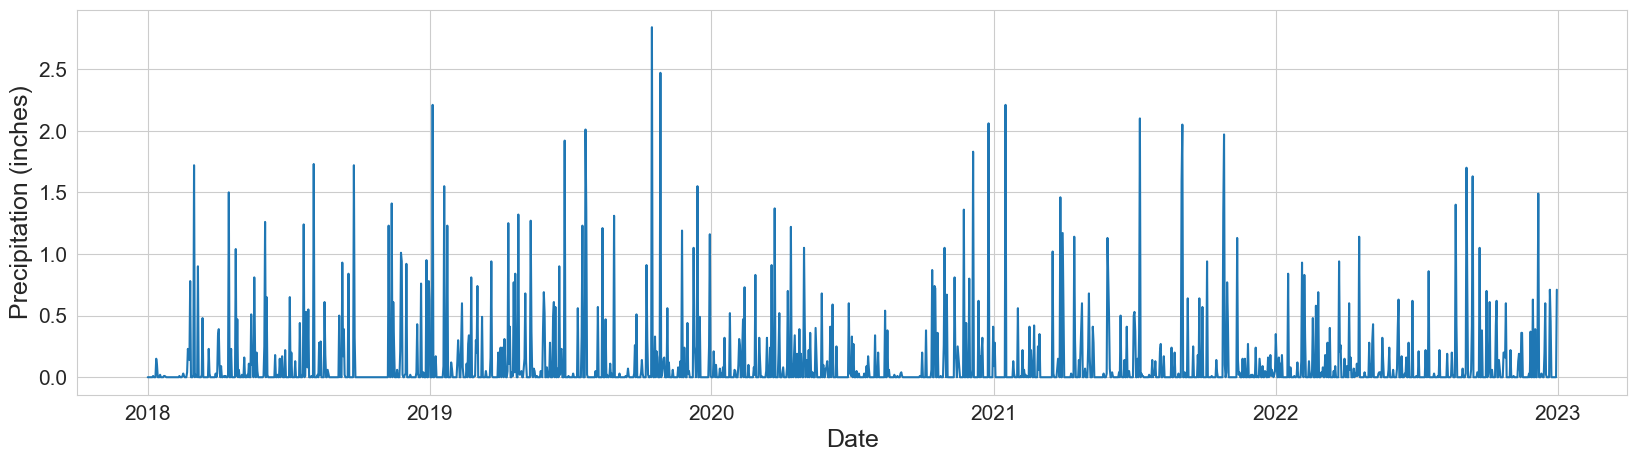

In [40]:
plt.figure(figsize=(20, 5))

sns.lineplot(data=df_london, x='DATE', y='PRCP')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

This graph shows the precipitation in **inches** for London from 2018 to 2022. The x-axis represents the years, while the y-axis represents the amount of precipitation.

From the graph, we can observe how precipitation changes over time. We can also see that London experienced its highest precipitation levels toward the end of **2019**, making this the most noticeable peak during the five-year period.

#### 3.2 Plotting precipitation for Seattle

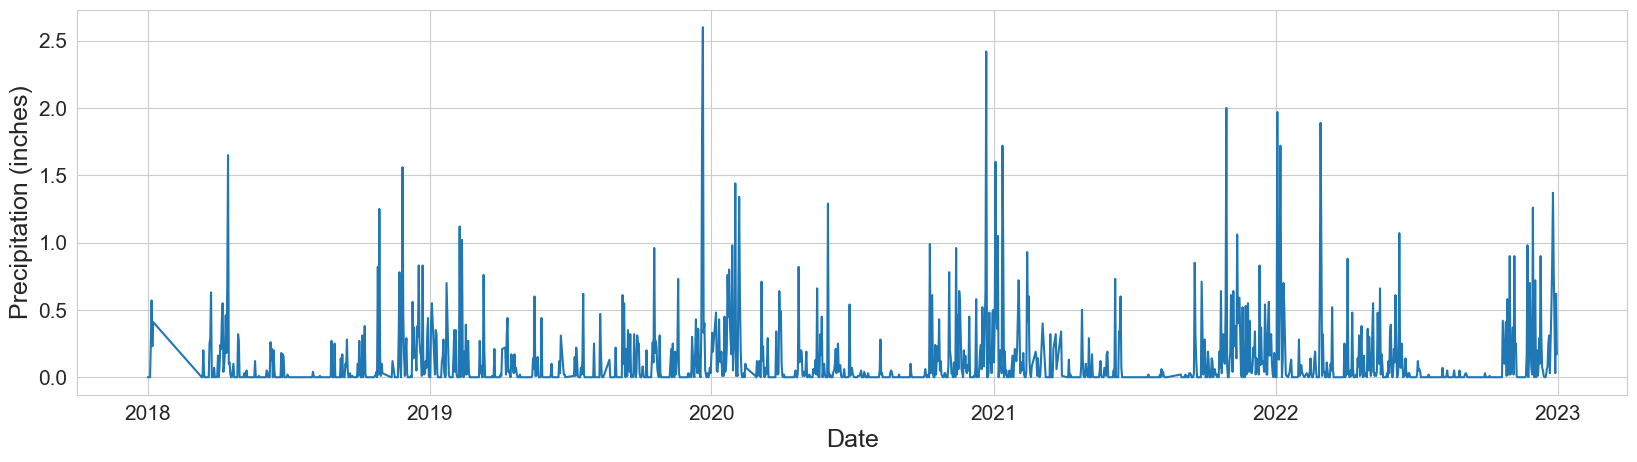

In [43]:
plt.figure(figsize=(20, 5))

sns.lineplot(data=df_seattle, x='DATE', y='PRCP')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

This graph shows the precipitation in **inches** for Seattle from 2018 to 2022. The x-axis represents the years, while the y-axis represents the amount of precipitation.

From the graph, we can observe how precipitation changes over time. We can also see that Seattle experienced its highest precipitation levels toward the end of **2019** and end of **2020**, making this the most noticeable peak during the five-year period.

## 4. Data Cleaning

#### 4.1 Join DataFrames keeping DATE and PRCP columns

In [47]:
df = df_london[['DATE','PRCP']].merge(df_seattle[['DATE','PRCP']], on='DATE', how='outer')

In [48]:
df

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.00,0.00
4,2018-01-05,NaN,0.25
...,...,...,...
1821,2022-12-27,0.00,0.78
1822,2022-12-28,0.00,0.40
1823,2022-12-29,0.00,0.03
1824,2022-12-30,0.00,0.62


We used the `.merge()` method to combine the London and Seattle datasets into a single DataFrame. This allows us to view the daily precipitation data for both cities side by side, making it easier to compare their precipitation on the same dates.

For this analysis, we kept only the columns that are relevant to our comparison: `DATE`, `CITY`, and `PRCP` (precipitation). Since both original datasets contained a column named `PRCP`, Pandas automatically renamed them after the merge to avoid having two columns with the same name. The London precipitation data is now stored in `PRCP_x`, while the Seattle precipitation data is stored in `PRCP_y`.

#### 4.2 Checking DataFrame statistical summary

In [51]:
df.describe()

,DATE,PRCP_x,PRCP_y
count,1826,1799.000000,1636.000000
mean,2020-07-01 12:00:00,0.112829,0.111852
min,2018-01-01 00:00:00,0.000000,0.000000
25%,2019-04-02 06:00:00,0.000000,0.000000
50%,2020-07-01 12:00:00,0.000000,0.010000
75%,2021-09-30 18:00:00,0.040000,0.110000
max,2022-12-31 00:00:00,2.840000,2.600000
std,NaN,0.300573,0.248635


The `.describe()` method shows us a statistical summary of our data. In this output, we have three columns and eight statistical measurements.

The `count` row shows the total number of non-null entries in each column. The `DATE` column has **1,826 entries**, `PRCP_x` (London) has **1,799 entries**, and `PRCP_y` (Seattle) has **1,636 entries**.

Since we are analyzing five years of data, from 2018 through 2022, we expect **1,826 days** in total. Normally, five years would contain 1,825 days (`5 × 365`), but **2020 was a leap year**, adding one additional day. Therefore, the `DATE` column contains all the expected dates. However, the lower counts for `PRCP_x` and `PRCP_y` show that precipitation values are missing from both cities.

The `.describe()` method also provides the `mean`, `min`, `25%` (first quartile), `50%` (second quartile or median), `75%` (third quartile), `max`, and `std` (standard deviation). These measurements help us better understand the distribution and variability of precipitation in each city.

#### 4.3 Creating a tidy date frame (reshape)

In [54]:
df = pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

In [55]:
df

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.00
3,2018-01-04,PRCP_x,0.00
4,2018-01-05,PRCP_x,NaN
...,...,...,...
3647,2022-12-27,PRCP_y,0.78
3648,2022-12-28,PRCP_y,0.40
3649,2022-12-29,PRCP_y,0.03
3650,2022-12-30,PRCP_y,0.62


We used the `.melt()` method to reshape our dataset from a wide format into a long format. Before using `.melt()`, the precipitation values for London and Seattle were stored in separate columns, `PRCP_x` and `PRCP_y`.

After using `.melt()`, the precipitation values from both cities are stored in a single precipitation column, while another column identifies which city each observation belongs to. This structure makes the dataset easier to organize, analyze, and visualize because both cities now use the same variables instead of having separate precipitation columns.

In [57]:
df.describe()

,DATE,precipitation
count,3652,3435.000000
mean,2020-07-01 12:00:00,0.112364
min,2018-01-01 00:00:00,0.000000
25%,2019-04-02 00:00:00,0.000000
50%,2020-07-01 12:00:00,0.000000
75%,2021-10-01 00:00:00,0.080000
max,2022-12-31 00:00:00,2.840000
std,NaN,0.277014


After reshaping our DataFrame with the `.melt()` method, we used `.describe()` again to examine the statistical summary of the newly structured dataset.

Since the London and Seattle precipitation values are now combined into a single `PRCP` column, `.describe()` gives us an overall summary of the precipitation observations from both cities. The `count` shows the number of non-null precipitation values, while the `mean`, `min`, `25%`, `50%`, `75%`, `max`, and `std` help us understand the distribution and variability of the combined precipitation data.

#### 4.4 Renaming columns values

In [60]:
df.loc[df['city']== 'PRCP_x', 'city'] = 'LDN'

In [61]:
df.loc[df['city']== 'PRCP_y', 'city'] = 'SEA'

In [62]:
df

,DATE,city,precipitation
0,2018-01-01,LDN,0.00
1,2018-01-02,LDN,0.00
2,2018-01-03,LDN,0.00
3,2018-01-04,LDN,0.00
4,2018-01-05,LDN,NaN
...,...,...,...
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62


Using `.loc[]`, we replaced `PRCP_x` and `PRCP_y` with more descriptive names. Now, our data identifies the rows as either `London` or `Seattle`. This makes our dataset easier to understand because we can clearly identify which precipitation observations belong to each city without having to remember what `PRCP_x` and `PRCP_y` represent.

#### 4.5 Standarzing column names

In [65]:
df = df.rename(columns={'DATE': 'date'})

In [66]:
df.head()

,date,city,precipitation
0,2018-01-01,LDN,0.0
1,2018-01-02,LDN,0.0
2,2018-01-03,LDN,0.0
3,2018-01-04,LDN,0.0
4,2018-01-05,LDN,NaN


## 5 Identify and fill in missing values

#### 5.1 Identifying where are the missing values

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  3435 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 85.7+ KB


The `.info()` method helps us see how many non-null values are present in each column. Here, we can see that the `precipitation` column contains only **3,435 non-null values out of 3,652 total entries**. This means that some precipitation values are missing from our dataset.

Before continuing with our analysis, we will need to decide how to handle these missing values. This is important because missing observations could affect our calculations and comparisons between London and Seattle.

In [71]:
df.isna().sum()

date               0
city               0
precipitation    217
dtype: int64

The `.isna().sum()` methods combined allow us to count how many missing (`NaN`) values are present in each column. The `.isna()` method checks whether each value is missing and returns `True` or `False`, while `.sum()` counts the `True` values.

In [73]:
df.loc[df['city'] == 'LDN', 'precipitation'].isna().sum()

27

In [74]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

190

We narrowed down our search to identify exactly where the precipitation data is missing. We performed the same missing-value check as before, but this time we also used `.loc[]` to filter the dataset by city.

By filtering for `London` and `Seattle` separately, we can see how many missing precipitation values belong to each city. This gives us a better understanding of how the missing data is distributed before deciding how to handle it.

#### 5.2 Impute missing values

We will replace missing values with the mean across years of values on that day.


##### 5.2.1 Defining a column that labels each day by day of the year

In [79]:
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

Instead of working only with the complete dates, we created a new column called `day_of_year`. This column represents each date by its position within the year, ranging from **1 to 366**.

For example, January 1st is represented as day `1`, January 2nd as day `2`, and so on. Since our dataset includes a leap year, the range can extend to day `366`.

The dataset still contains **3,652 rows**, but the new `day_of_year` column allows us to group and compare the same days across different years. This will be useful when handling missing precipitation values because we can compare a missing observation with precipitation recorded around the same time of year in other years.

##### 5.2.2 Compute the mean precipitation for each day in London, averaged across years.

In [82]:
mean_day_precipitation_london=df.loc[
    df['city']=='LDN',
    ['precipitation','day_of_year']
].groupby(
    'day_of_year'
).mean()

We used the `.groupby()` method to group the London data by `day_of_year` and then calculated the **mean precipitation** for each day across the five years.

For example, `.groupby()` groups all observations for January 1st together, allowing us to calculate the mean precipitation for that specific day across the five-year period. The same process is repeated for January 2nd, January 3rd, and so on throughout the year.

These daily averages will help us estimate the missing precipitation values based on the precipitation recorded on the same day of the year during the other years in our dataset.

In [84]:
mean_day_precipitation_london

,precipitation
day_of_year,
1,0.214
2,0.086
3,0.000
4,0.042
5,0.605
...,...
362,0.196
363,0.050
364,0.236


Calling `mean_day_precipitation_london` allows us to view the beginning and end of the calculated daily precipitation averages. Each `day_of_year` is associated with its respective mean precipitation across the five-year period.

For example, day `1`, which represents January 1st, has an average precipitation of **0.214 inches**, while day `2`, representing January 2nd, has an average of **0.086 inches**.

##### 5.2.3 Plotting London's Precipitation Based on the Daily Mean

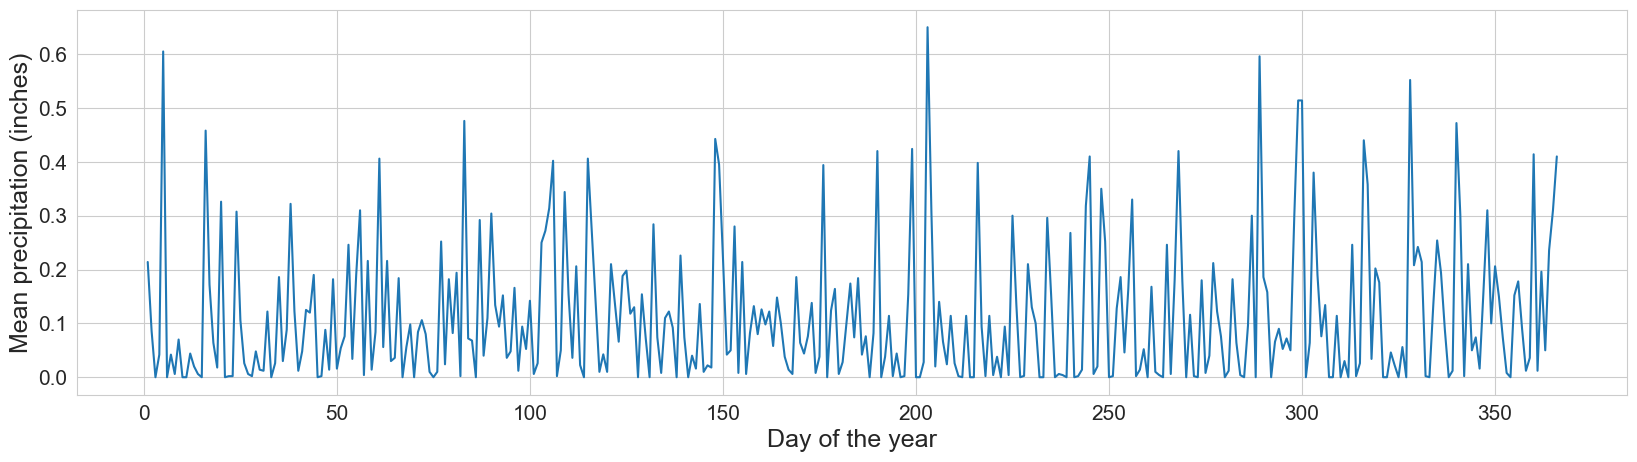

In [87]:
plt.figure(figsize=(20,5))

sns.lineplot(data=mean_day_precipitation_london, x='day_of_year', y='precipitation')

plt.xlabel('Day of the year', fontsize=18)
plt.ylabel('Mean precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

The graph shows London's **mean daily precipitation in inches throughout the year**, based on the precipitation data collected from 2018 to 2022. The x-axis represents the `day_of_year`, while the y-axis represents the average precipitation in inches. This allows us to visualize how London's typical precipitation levels change throughout the year.

##### 5.2.4 Compute the mean precipitation for each day in Seattle, averaged across years.

In [90]:
mean_day_precipitation_seattle=df.loc[
    df['city']=='SEA',
    ['precipitation','day_of_year']
].groupby(
    'day_of_year'
).mean()

We used the `.groupby()` method to group the Seattle data by `day_of_year` and then calculated the **mean precipitation** for each day across the five years.

For example, `.groupby()` groups all observations for January 1st together, allowing us to calculate the mean precipitation for that specific day across the five-year period. The same process is repeated for January 2nd, January 3rd, and so on throughout the year.

These daily averages will help us estimate the missing precipitation values based on the precipitation recorded on the same day of the year during the other years in our dataset.

In [92]:
mean_day_precipitation_seattle

,precipitation
day_of_year,
1,0.052000
2,0.150000
3,0.836000
4,0.370000
5,0.246667
...,...
362,0.120000
363,0.102000
364,0.268000


Calling `mean_day_precipitation_seattle` allows us to view the beginning and end of the calculated daily precipitation averages. Each `day_of_year` is associated with its respective mean precipitation across the five-year period.

For example, day `1`, which represents January 1st, has an average precipitation of **0.052 inches**, while day `2`, representing January 2nd, has an average of **0.150 inches**.

##### 5.2.5 Plotting Seattle's Precipitation Based on the Daily Mean

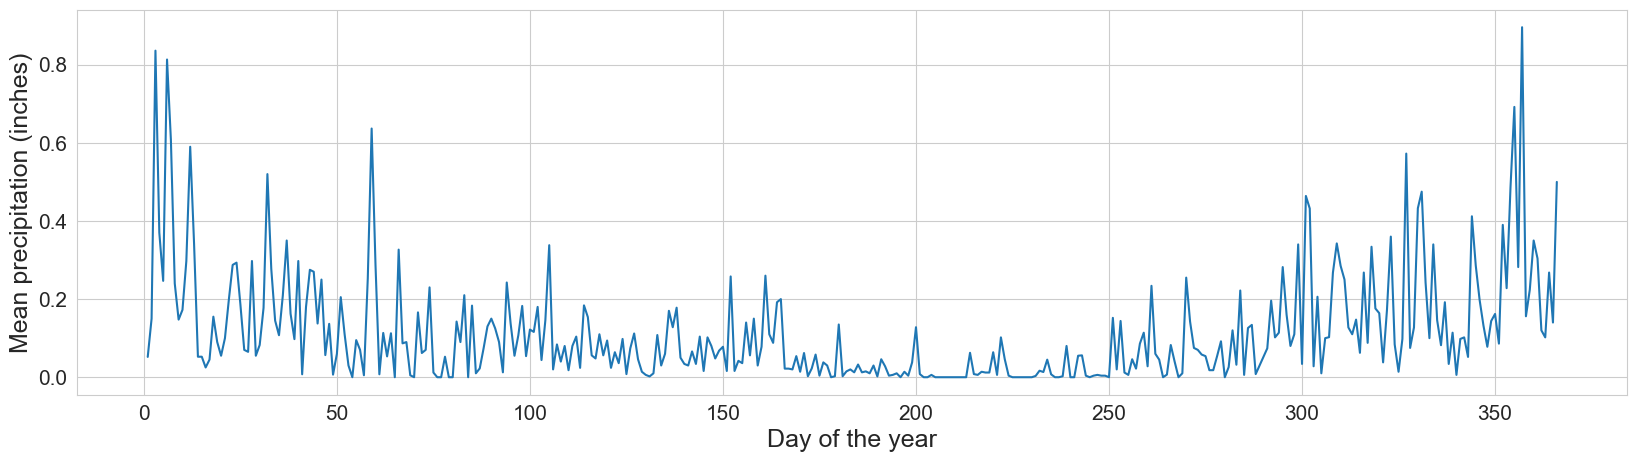

In [95]:
plt.figure(figsize=(20,5))

sns.lineplot(data=mean_day_precipitation_seattle, x='day_of_year', y='precipitation')

plt.xlabel('Day of the year', fontsize=18)
plt.ylabel('Mean precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

The graph shows Seattle's **mean daily precipitation in inches throughout the year**, based on the precipitation data collected from 2018 to 2022. The x-axis represents the `day_of_year`, while the y-axis represents the average precipitation in inches. This allows us to visualize how Seattle's typical precipitation levels change throughout the year.

##### 5.2.6 Get the index of each row where precipitation is missing.

In [98]:
indices_london = np.where(
    (df['city'] == 'LDN') & (df['precipitation'].isna())
)[0]

In [99]:
indices_london

array([   4,   23,   35,   38,   98,  147,  148,  275,  293,  294,  296,
        300,  306,  307,  310,  406,  991, 1050, 1051, 1208, 1209, 1321,
       1322, 1323, 1380, 1533, 1579])

The `where()` method helps us identify the positions in the dataset where precipitation values are missing. By combining it with `.isna()`, we can locate the rows where the precipitation value is `NaN`.

For example, in the London data, we can see missing precipitation values at positions **4, 23, 35, 38**, and so on. Identifying these positions allows us to know exactly where the missing values are located so that we can replace them with the corresponding daily mean precipitation calculated earlier.

In [101]:
indices_seattle = np.where(
    (df['city'] == 'SEA') & (df['precipitation'].isna())
)[0]

In [102]:
indices_seattle

array([1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844,
       1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855,
       1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866,
       1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877,
       1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888,
       1889, 1890, 1891, 1892, 1893, 1894, 1895, 2090, 2131, 2132, 2133,
       2134, 2135, 2136, 2137, 2138, 2139, 2140, 2195, 2196, 2197, 2214,
       2215, 2244, 2245, 2246, 2247, 2248, 2249, 2286, 2287, 2288, 2362,
       2363, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377,
       2417, 2418, 2419, 2420, 2421, 2422, 2423, 2517, 2518, 2519, 2520,
       2521, 2522, 2523, 2524, 2559, 2560, 2561, 2602, 2603, 2604, 2605,
       2606, 2607, 2608, 2609, 2610, 2611, 2612, 2818, 2819, 2820, 2821,
       2822, 2823, 2824, 2825, 2826, 2827, 2972, 2973, 2974, 2975, 2983,
       2984, 2986, 2987, 2988, 3000, 3001, 3004, 30

We performed the same process for Seattle, using `where()` combined with `.isna()` to identify the positions where precipitation values are missing.

From the results, we can see that the Seattle dataset contains **many more missing precipitation values than the London dataset**. Earlier, we identified **190 missing values for Seattle compared with 27 for London**. Locating these missing values allows us to replace them with the corresponding daily mean precipitation calculated from the available data.

#### 5.3 Replace each missing value with the mean on that day

##### 5.3.1 Replacing for London

In [106]:
for index in indices_london:
    df.loc[index,'precipitation'] = mean_day_precipitation_london.loc[df.loc[index, 'day_of_year']].values[0]

We used a `for` loop to go through each position where London has a missing precipitation value.

For each missing value, we first identify which `day_of_year` that row belongs to. For example, if the missing value occurred on January 4th, its `day_of_year` would be `4`.

We then look at the daily means we calculated earlier and find the average precipitation for day `4`. The `.values[0]` part retrieves that precipitation value, and we use `.loc[]` to place it into the row where the precipitation was originally missing.

In other words, each missing value is replaced with the average precipitation for the same day of the year based on the available data from the other years.

##### 5.3.2 Replacing for Seattle

In [109]:
for index in indices_seattle:
    df.loc[index,'precipitation'] = mean_day_precipitation_seattle.loc[df.loc[index, 'day_of_year']].values[0]

We repeated the same process for the missing precipitation values in Seattle. Using a `for` loop, we went through each position where Seattle had a missing precipitation value.

##### 5.3.3 Checking for the null values

In [112]:
df.isna().sum()

date             0
city             0
precipitation    0
day_of_year      0
dtype: int64

After filling in the missing precipitation values, we used `.isna().sum()` again to check if there were any `NaN` values remaining in our dataset.

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  3652 non-null   float64       
 3   day_of_year    3652 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(1)
memory usage: 100.0+ KB


We used the `.info()` method one more time to confirm that our dataset is complete after filling in the missing precipitation values. We can now see that all columns contain the same **3,652 non-null values**, which matches the total number of rows in our dataset.

## 6. Data analysis

#### 6.1 Checking which city had more days with precipitation during the 5 years period

In [118]:
rainy_days_london = df.loc[
    (df['city'] == 'LDN') & (df['precipitation'] > 0)
].shape[0]

print(rainy_days_london)

634


In [119]:
rainy_days_seattle = df.loc[
    (df['city'] == 'SEA') & (df['precipitation'] > 0)
].shape[0]

print(rainy_days_seattle)

999


We are using `.shape[0]` to count all the days that had precipitation greater than 0.0 inches during the five-year period. This allows us to compare which city had more days with precipitation. Out of 1,826 days between 2018 and 2022, London had 634 days with precipitation greater than 0.0 inches, representing approximately 34.7% of the days. Seattle had 999 days with precipitation greater than 0.0 inches, representing approximately 54.7% of the days. Based on these results, Seattle had precipitation more frequently than London during the five-year period.

#### 6.2 Checking which city had a higher precipitation during the 5 years period

In [122]:
sum_london = df.loc[df['city'] == 'LDN', 'precipitation'].sum()

print(sum_london)

205.615


In [123]:
sum_seattle = df.loc[df['city'] == 'SEA', 'precipitation'].sum()

print(sum_seattle)

206.83166666666668


During the five-year period between 2018 and 2022, London had a total precipitation of 205.615 inches, while Seattle had a total of 206.832 inches. Even though Seattle had significantly more days with precipitation than London, the total amount of precipitation received by both cities was very similar. Seattle received only about 1.217 inches more precipitation than London across the entire five-year period.

#### 6.3 Checking the total yearly precipitation for each city in inches

In [184]:
df['year'] = df['date'].dt.year

yearly_precipitation = df.groupby(['year', 'city'])['precipitation'].sum()

print(yearly_precipitation)

year  city
2018  LDN     39.217500
      SEA     37.244167
2019  LDN     54.525000
      SEA     38.653333
2020  LDN     36.360000
      SEA     43.221667
2021  LDN     38.550000
      SEA     44.434167
2022  LDN     36.962500
      SEA     43.278333
Name: precipitation, dtype: float64


We are extracting the year from each date so we can use `.groupby()` to group the data by year and city. Then, we use `.sum()` to calculate the total precipitation for each group. This allows us to compare the yearly precipitation for London and Seattle throughout the five-year period.

#### 6.4 Checking how many days of the year the precipitation was bigger than zero for each city

In [188]:
rainy_days = (
    df[df['precipitation'] > 0]
    .groupby(['year', 'city'])['date']
    .count()
)

print(rainy_days)

year  city
2018  LDN     126
      SEA     187
2019  LDN     142
      SEA     195
2020  LDN     115
      SEA     222
2021  LDN     122
      SEA     202
2022  LDN     129
      SEA     193
Name: date, dtype: int64


Now, we are filtering the days when precipitation was greater than 0.0 inches and grouping them by year and city. Then, we count the number of days in each group so we can see how many days had precipitation each year in London and Seattle.

#### 6.5 Create a line plot of precipitation over time for each city

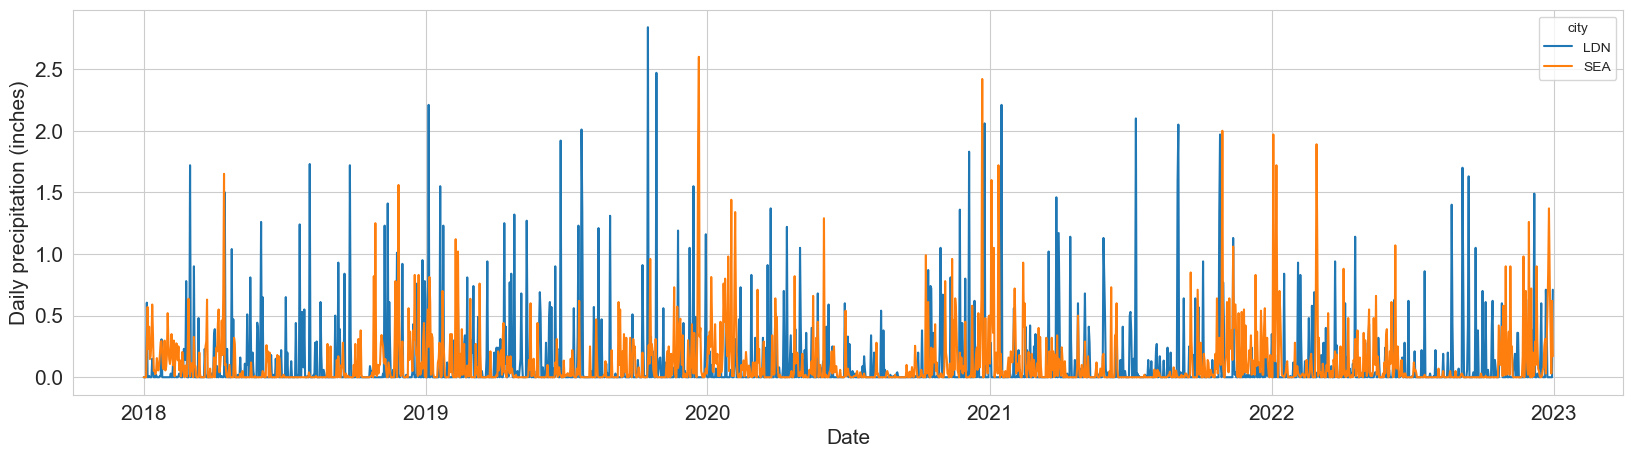

In [192]:
plt.figure(figsize=(20, 5))

sns.lineplot(data=df, x='date', y='precipitation', hue='city')

plt.xlabel('Date', fontsize=15)
plt.ylabel('Daily precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

This graph shows the yearly precipitation in inches for each city from 2018 to 2022. London is represented in blue, while Seattle is represented in orange. This allows us to visually compare the total amount of precipitation each city received each year.

#### 6.6 Calculate basic descriptive statistics using groupby and describe

In [196]:
df[['city', 'precipitation']].groupby('city').describe()

precipitation                                                    
             count      mean       std  min  25%   50%       75%   max
city                                                                  
LDN         1826.0  0.112604  0.298927  0.0  0.0  0.00  0.041875  2.84
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.120000  2.60

With the data cleaned and the missing precipitation values filled, we applied the `.describe()` method again to examine the updated descriptive statistics. The results show only small changes compared with the statistics before handling the missing values, suggesting that filling the missing observations did not substantially change the overall precipitation patterns in the dataset.

#### 6.7 Create a bar plot of mean daily precipitation for each city

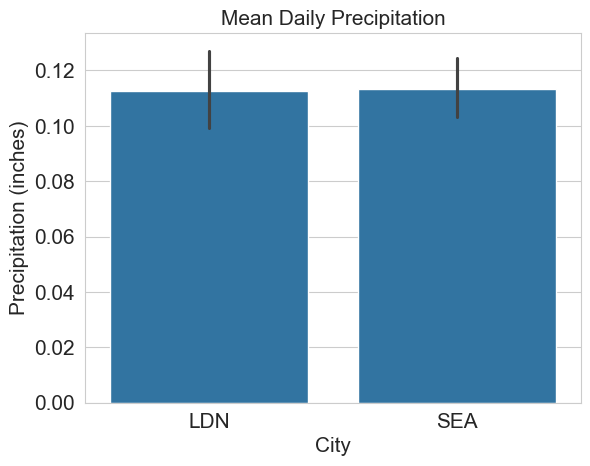

In [200]:
sns.barplot(data=df, x='city', y='precipitation')

plt.ylabel('Precipitation (inches)', fontsize=15)
plt.xlabel('City', fontsize=15)
plt.title('Mean Daily Precipitation', fontsize=15)


plt.tick_params(labelsize=15)

plt.show()

This bar plot shows that the mean daily precipitation for London and Seattle is very similar. The small difference between the two bars indicates that, on average, both cities received nearly the same amount of precipitation per day during the five-year period.

#### 6.8 Add a new column to the data frame indicating the month

In [204]:
df['month'] = pd.DatetimeIndex(df['date']).month

In [206]:
df.head()

,date,city,precipitation,day_of_year,year,month,any_precipitation
0,2018-01-01,LDN,0.000,1,2018,1,False
1,2018-01-02,LDN,0.000,2,2018,1,False
2,2018-01-03,LDN,0.000,3,2018,1,False
3,2018-01-04,LDN,0.000,4,2018,1,False
4,2018-01-05,LDN,0.605,5,2018,1,True


In [208]:
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

We extracted the month from the `date` column and created a new column to represent the month of each observation. After applying the `.unique()` method to the month column, we can confirm that the dataset contains all 12 months of the year.

#### 6.9 Create a box plot of precipitation by month for each city

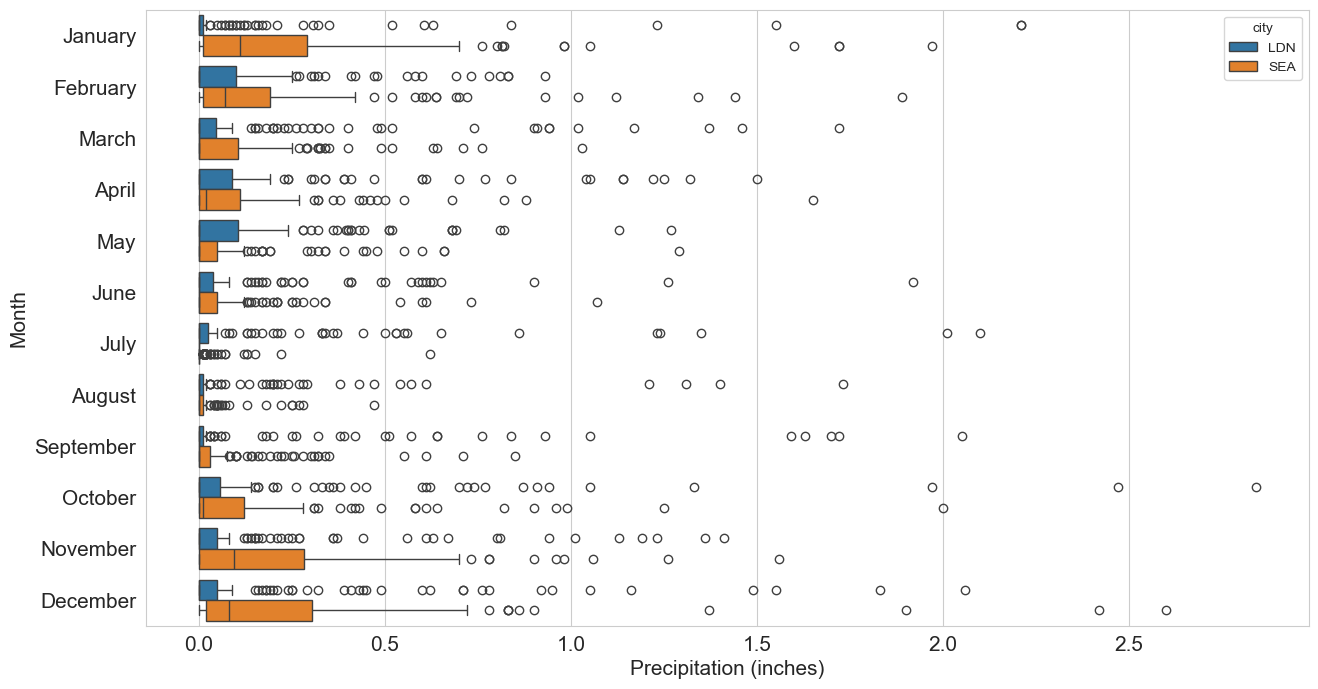

In [218]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df, x='precipitation', y='month', hue='city', orient='h')

plt.ylabel('Month', fontsize=15)
plt.xlabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

import calendar 
month_names = list(calendar.month_name[1:])

plt.yticks(ticks=range(12), labels=month_names)

plt.show()

Using a box plot, we can visualize the distribution of precipitation for each month. The graph allows us to compare the precipitation patterns across the months while also helping us identify possible outliers, represented by values that fall far from the typical range of precipitation.

#### 6.10 Create a resized box plot of precipitation by month for each city

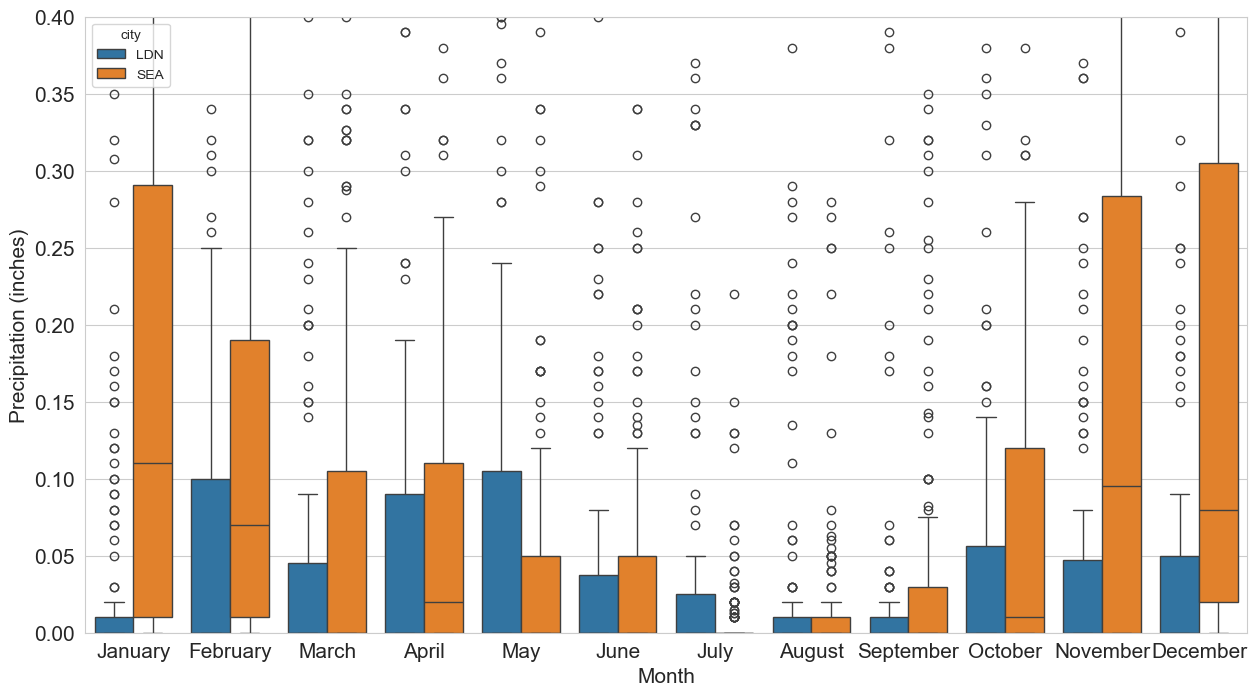

In [216]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.ylim(0, 0.4)

plt.show()

We created a zoomed-in version of the box plot to get a clearer view of the monthly precipitation distribution for London and Seattle. By reducing the range of the y-axis, we can better observe the boxes, medians, and differences between the two cities that were difficult to see in the previous graph because of the outliers.

#### 6.11 Create a bar plot of mean precipitation by month for each city

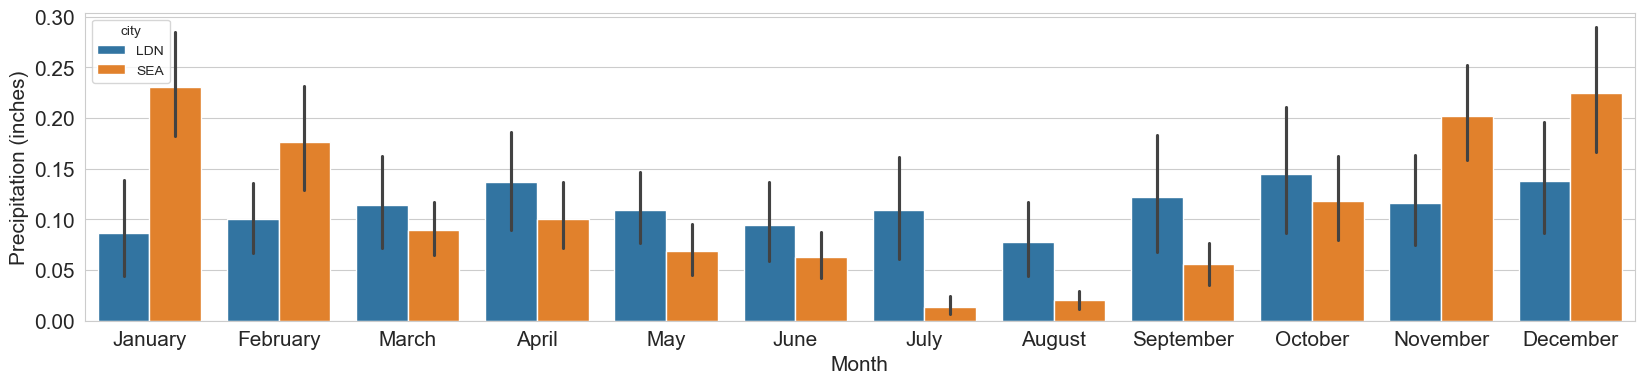

In [220]:
plt.figure(figsize=(20, 4))

sns.barplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.show()

This bar plot shows the mean monthly precipitation in inches for London and Seattle over the five-year period. London is represented in blue, while Seattle is represented in orange. We can see that Seattle has higher mean precipitation during the winter months, especially from November through February, while July and August have very little precipitation. In comparison, London generally has higher mean precipitation than Seattle from March through October.

#### 6.12 Calculate mean precipitation by city and month using groupby

In [151]:
df[['month', 'precipitation', 'city']].groupby(['city', 'month']).mean()

precipitation
city month               
LDN  1           0.087048
     2           0.100621
     3           0.114645
     4           0.136983
     5           0.109597
     6           0.094467
     7           0.108839
     8           0.077919
     9           0.121667
     10          0.144790
     11          0.115800
     12          0.138387
SEA  1           0.230742
     2           0.176472
     3           0.089075
     4           0.100483
     5           0.069161
     6           0.063167
     7           0.013984
     8           0.019995
     9           0.055622
     10          0.118452
     11          0.201867
     12          0.224903

After observing the patterns in the graph, we used `.groupby()` and `.mean()` to calculate the mean monthly precipitation for each city and confirm what we observed visually. Seattle has a mean precipitation of approximately 0.23 inches in January and 0.22 inches in December, compared with only about 0.01 inches in July and August. London has a mean precipitation of approximately 0.08 inches in January and 0.13 inches in December, while April and October have higher values of approximately 0.13 and 0.14 inches, respectively. These values support the seasonal differences observed in the graph.

#### 6.13 Add a new column indicating if any precipitation occurred

In [155]:
df['any_precipitation'] = df['precipitation'] > 0

In [157]:
df.head()

,date,city,precipitation,day_of_year,year,month,any_precipitation
0,2018-01-01,LDN,0.000,1,2018,1,False
1,2018-01-02,LDN,0.000,2,2018,1,False
2,2018-01-03,LDN,0.000,3,2018,1,False
3,2018-01-04,LDN,0.000,4,2018,1,False
4,2018-01-05,LDN,0.605,5,2018,1,True


We created a new column in the dataset called `any_precipitation`, which returns `True` for days with precipitation greater than 0 inches and `False` for days with 0 inches of precipitation. This allows us to compare the proportion of days with precipitation between the two cities. We already know that Seattle had more days with precipitation than London, with 999 days compared with 634 days. Using this new column, we can now examine what proportion of the total days had precipitation in each city.

#### 6.14 Calculate and plot the proportion of days with any precipitation

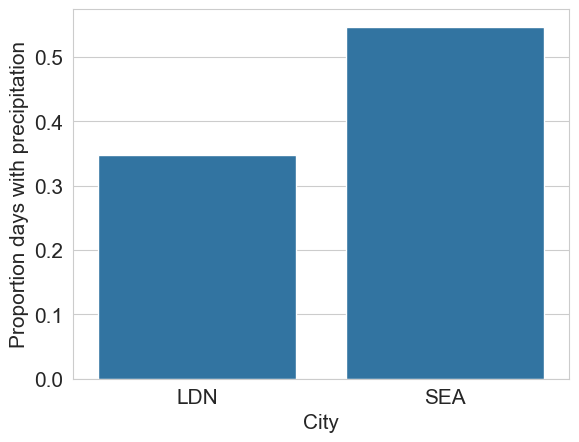

In [161]:
sns.barplot(data=df, x='city', y='any_precipitation', errorbar=None)

plt.xlabel('City', fontsize=15)
plt.ylabel('Proportion days with precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

As the bar plot shows, Seattle had precipitation on approximately 55% of the days during the five-year period, while London had precipitation on approximately 35% of the days. This confirms that Seattle experienced precipitation more frequently than London, even though the total amount of precipitation between the two cities was very similar.

#### 6.15 Create a Bar Plot of the Proportion of Days With Precipitation by Month

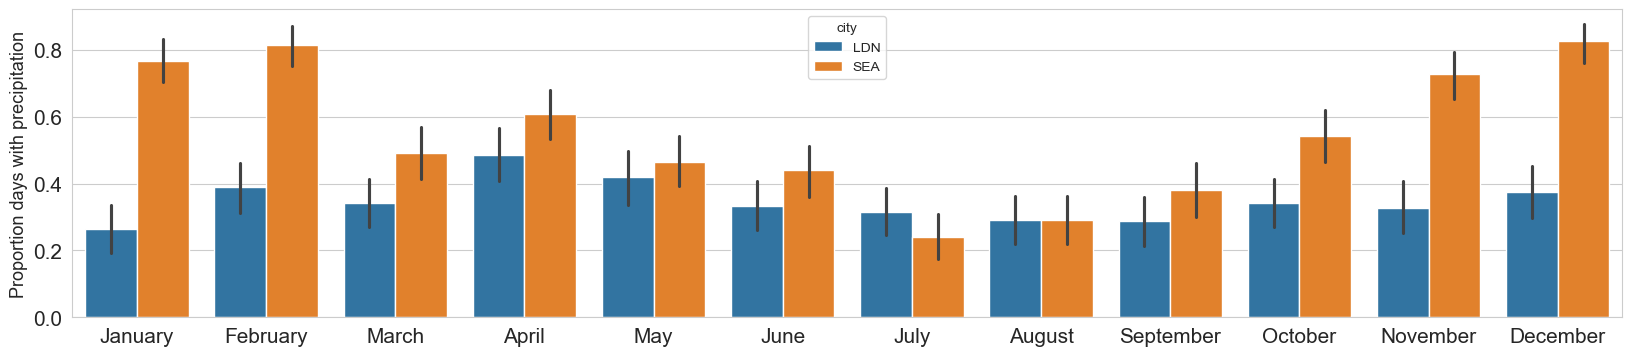

In [222]:
plt.figure(figsize=(20, 4))

sns.barplot(data=df, x='month', y='any_precipitation', hue='city')

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.xticks(ticks=range(12), labels=month_names)

plt.tick_params(labelsize=15)

plt.show()

This bar plot shows that even though London has more months with higher mean precipitation amounts, Seattle has a higher proportion of days with precipitation throughout most of the year. Seattle is ahead of London in approximately 10 out of the 12 months, showing that precipitation occurs more frequently in Seattle even when London receives a higher average amount of precipitation during some months.

#### 6.16 Perform a statistical test for differences in the mean precipitation each month between the cities

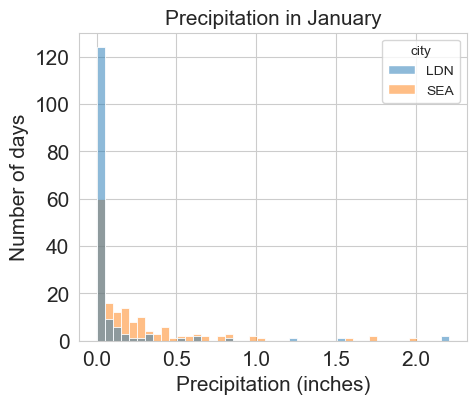

In [167]:
plt.figure(figsize=(5, 4))

sns.histplot(data=df.loc[df['month'] == 1], x ='precipitation', hue='city')

plt.xlabel('Precipitation (inches)', fontsize=15)
plt.ylabel('Number of days', fontsize=15)
plt.title('Precipitation in January', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

This histogram shows how precipitation is distributed during January for both cities. London has many more days with little or no precipitation, while Seattle has more days with higher amounts of precipitation. This helps us understand why Seattle has a higher average precipitation in January.

In [ ]:
from scipy import stats

In [ ]:
significance_level = 0.05
significantly_different = np.zeros(12)

#Perform t-tests for each month
for month in range(1, 13):
    #Get precipitation data for Seattle and St. Louis for current month 
    sea_data = df.loc[(df['city'] == 'SEA') & (df['month'] == month), 'precipitation']
    stl_data = df.loc[(df['city'] == 'LDN') & (df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, stl_data, equal_var=False)

    if p_value < significance_level:
        significantly_different[month-1] = 1

    print(f"Month {month}:")
    print(f" t-statistic = {t_statistic:.2f}")
    print(f" p-value = {p_value:.3f}")
    print("-" * 20)


We performed a **t-test**, a statistical test used to compare the averages of two groups and determine whether the difference between them is likely meaningful rather than due to random variation. We performed the test for each month to compare the mean precipitation between Seattle and London. We used a significance level of **0.05**. If the p-value is below 0.05, we consider the difference between the two cities statistically significant for that month.

#### 6.17 Plot the mean precipitation each month with a star for significant differences

In [ ]:
plt.figure(figsize=(20, 4))

sns.barplot(data=df, x='month', y='precipitation', hue='city', alpha=0.75)

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)
plt.title('Mean monthly precipitation', fontsize=15, loc='center')
plt.legend(title='city', bbox_to_anchor=(1, 1), loc='upper left')

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months 
for month in range(12):
    if significantly_different[month] == 1:

        #Add a star
        plt.text(month, 0.27, '*', ha='center', fontsize=25)
plt.show()

This bar plot compares the mean monthly precipitation between Seattle and London. The stars represent the months where the t-test found a statistically significant difference between the two cities (p-value < 0.05). This makes it easier to see not only which city has higher precipitation each month, but also which differences are statistically significant.

#### 6.18 Perform a statistical test for differences in the proportion of days with any precipitation each month between the cities

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different_proportion = np.zeros(12)

for month in range(1, 13):
     
    contingency_table = pd.crosstab(
        df.loc[df['month'] == month, 'city'], df.loc[df['month'] == month, 'any_precipitation']
    )
    
    days_with_precipitation = contingency_table[True]

    total_counts = contingency_table.sum(axis=1)

    #Hypotesis test 
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, nobs=total_counts, alternative='two-sided'
    )
    
    
    if p_value < significance_level:
        significantly_different_proportion[month-1] = 1

    print(f"Month {month}:")
    print(f" t-statistic = {zstat:.2f}")
    print(f" p-value = {p_value:.3f}")
    print("-" * 20)


We performed a proportion z-test for each month to determine if the proportion of days with precipitation is significantly different between Seattle and London. The test compares how frequently precipitation occurred in each city. We used a significance level of 0.05, meaning that a p-value below 0.05 indicates a statistically significant difference.

In [ ]:
contingency_table = pd.crosstab(
    df.loc[df['month'] == 1, 'city'], df.loc[df['month'] == 1, 'any_precipitation']
)

contingency_table

The contingency table shows that in January, London had 41 days with precipitation and 114 days without precipitation, while Seattle had 119 days with precipitation and only 36 days without precipitation. This shows that precipitation occurred much more frequently in Seattle during January.

In [ ]:
plt.figure(figsize=(20, 4))

sns.barplot(data=df, x='month', y='any_precipitation', hue='city', alpha=0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.title('Monthly proportion of days with precipitation', fontsize=15)

plt.xticks(ticks=range(12), labels=month_names)
plt.tick_params(labelsize=15)


# Add stars for significantly different months 
for month in range(12):
    if significantly_different_proportion[month] == 1:

        #Add a star
        plt.text(month, 0.825, '*', ha='center', fontsize=25)
plt.show()

This bar plot shows the monthly proportion of days with precipitation for Seattle and London. The stars indicate the months where the difference between the two cities is statistically significant based on the proportion z-test.

## 7 Export the clean .csv file

In [ ]:
df.to_csv(
    '/Users/marianabutarov/Data_Science/Weather Project/clean_seattle_london_weather.csv',
    encoding='utf-8-sig',
    index=False
)